# Explore test ascii files

Visualize `z` over time in the ascii files from test resources.

First import and initialize general stuff:

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np

# Just a hack to be able to `import gutils`
sys.path.append(str(Path('.').absolute().parent.parent))


Define a ascii to dataframe reader helper:

In [2]:
from gutils.slocum import SlocumReader

def ascii_into_df(path):
    slocum_data = SlocumReader(path)
    print('ASCII: ', slocum_data.ascii_file)
    return slocum_data.standardize()

Define a plotting helper. It plots `z` over time and if dataframe has a `profile` column
it also uses it to set color to diferentiate detected profiles.

Note: profile `NaN` values are plotted as index `-1`.

In [3]:
import matplotlib.dates as mpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_z(dataframe: pd.DataFrame):
    df = dataframe.copy()
    df['z'] = df.z.values * -1
    df['t'] = mpd.date2num(df.t.dt.to_pydatetime())

    if 'profile' in df.columns:
        df.loc[df['profile'].isna(), 'profile'] = -1

        # Get unique profile values and create a colormap for only those values
        unique_profiles = np.sort(df['profile'].convert_dtypes(convert_floating=True).unique())
        cmap = ListedColormap(plt.cm.tab20(np.linspace(0, 1, len(unique_profiles))))

        # Create a scatter plot
        df.plot.scatter(x='t', y='z', c='profile', cmap=cmap, colorbar=False)

        # Add a legend for the unique profile values
        handles = [
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap(i / len(unique_profiles)), markersize=10, label=int(profile))
            for i, profile in enumerate(unique_profiles)
        ]
        plt.legend(handles=handles, title="Profile", loc="best")
    else:
        df.plot.scatter(x='t', y='z')

    plt.show()



If desired, use this functino to see how profiles would be filtered:

In [4]:
from gutils.filters import default_filter
from gutils.yo import count_profiles

def filter_data(profiles):
    original_count = count_profiles(profiles)
    filtered, stats = default_filter(profiles)
    print(
        f'Filtered {stats["total_removed"]}/{original_count} profiles - '
        + ', '.join(
            f'{variable.capitalize()} ({stats[variable]["filter_val"]}{unit}): {stats[variable]["removed"]}'
            for variable, unit in [('depth', 'm'), ('points', ''), ('time', 's'), ('distance', 'm')]
        )
    )

    return filtered

## Finally plot some files

Plot all the ascii files used in `test_filters.py` to visually verify stuff is doing what it should be.

ASCII:  ../../gutils/tests/resources/slocum/unit_191-20250226T0000/rt/ascii/unit_191_2025_069_2_355_sbd.dat
unit_191_2025_069_2_355_sbd.dat


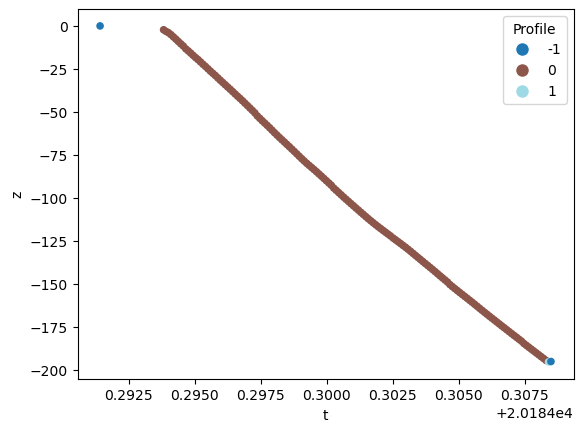

ASCII:  ../../gutils/tests/resources/slocum/unit_191-20250226T0000/rt/ascii/unit_191_2025_059_1_17_sbd.dat
unit_191_2025_059_1_17_sbd.dat


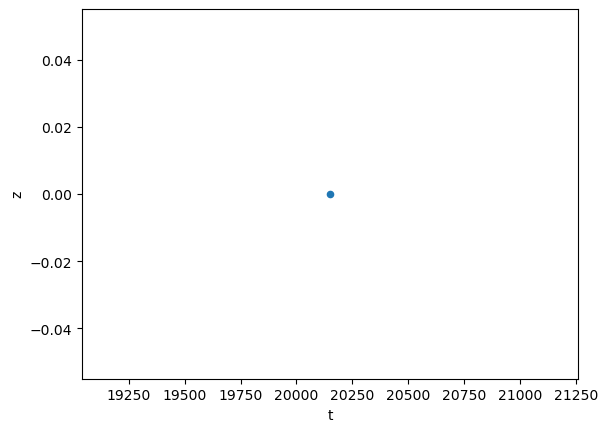

ASCII:  ../../gutils/tests/resources/slocum/unit_191-20250226T0000/rt/ascii/unit_191_2025_098_0_16_sbd.dat
unit_191_2025_098_0_16_sbd.dat


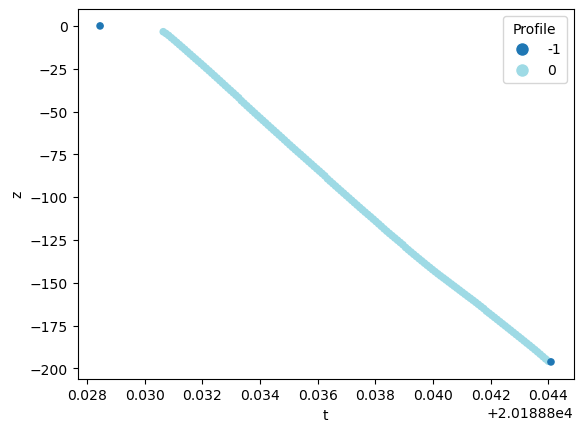

ASCII:  ../../gutils/tests/resources/slocum/unit_191-20250226T0000/rt/ascii/unit_191_2025_069_2_45_sbd.dat
unit_191_2025_069_2_45_sbd.dat


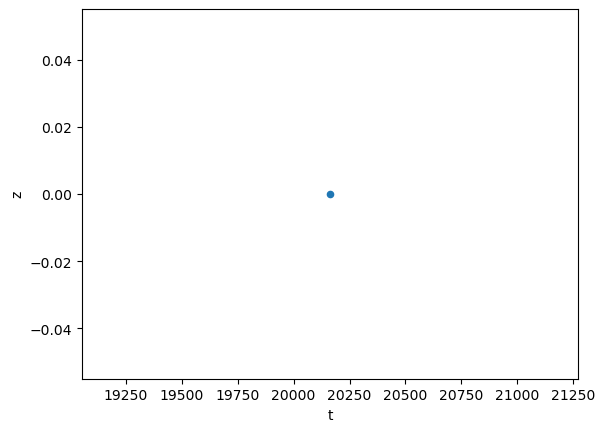

ASCII:  ../../gutils/tests/resources/slocum/unit_191-20250226T0000/rt/ascii/unit_191_2025_098_0_14_sbd.dat
unit_191_2025_098_0_14_sbd.dat


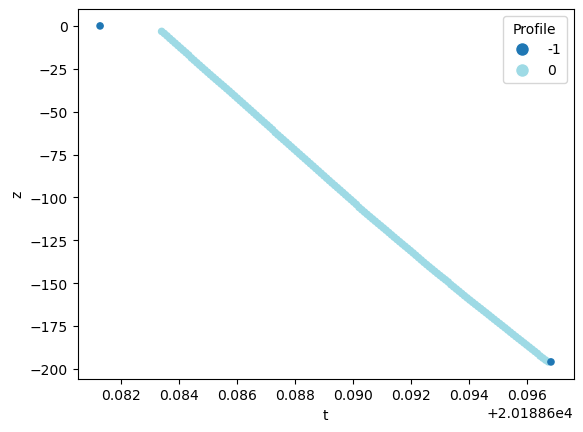

ASCII:  ../../gutils/tests/resources/slocum/unit_191-20250226T0000/rt/ascii/unit_191_2025_069_2_23_sbd.dat
unit_191_2025_069_2_23_sbd.dat


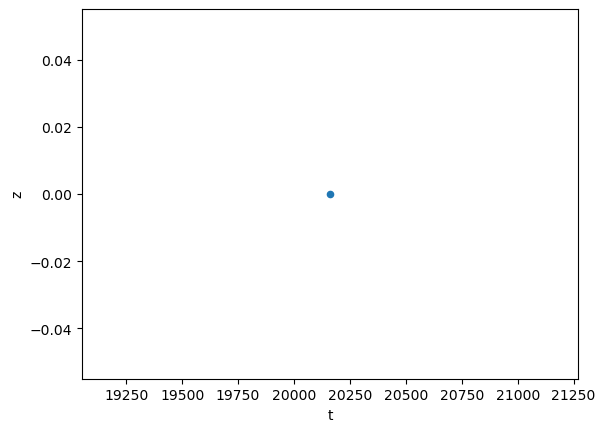

ASCII:  ../../gutils/tests/resources/slocum/unit_191-20250226T0000/rt/ascii/unit_191_2025_069_2_198_sbd.dat
unit_191_2025_069_2_198_sbd.dat


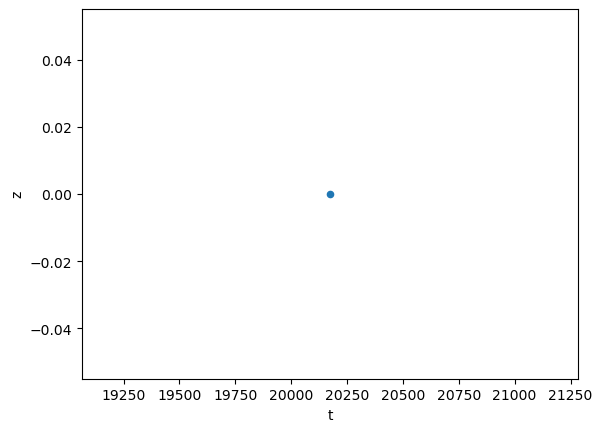

ASCII:  ../../gutils/tests/resources/slocum/unit_191-20250226T0000/rt/ascii/unit_191_2025_063_0_16_sbd.dat
unit_191_2025_063_0_16_sbd.dat


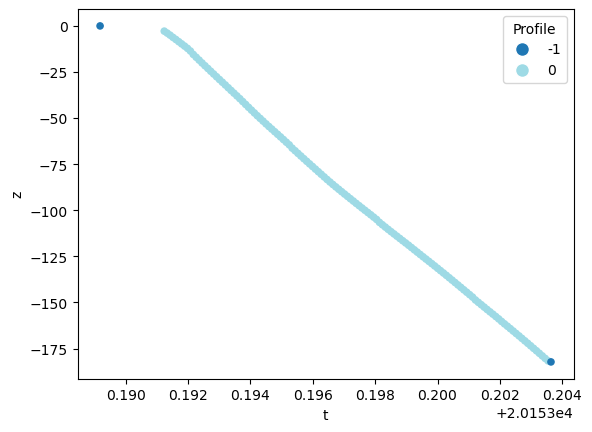

ASCII:  ../../gutils/tests/resources/slocum/unit_191-20250226T0000/rt/ascii/unit_191_2025_063_0_24_sbd.dat
unit_191_2025_063_0_24_sbd.dat


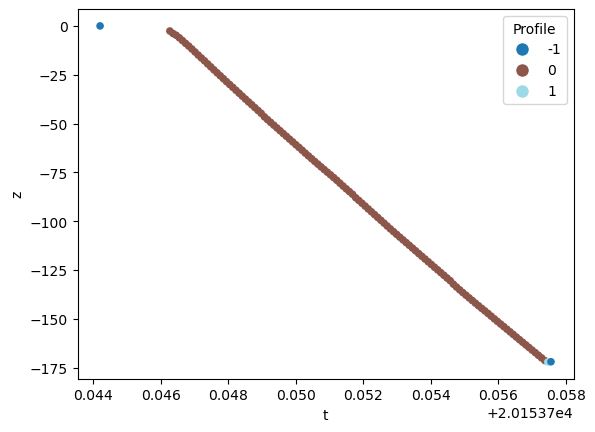

ASCII:  ../../gutils/tests/resources/slocum/unit_191-20250226T0000/rt/ascii/unit_191_2025_098_0_145_sbd.dat
unit_191_2025_098_0_145_sbd.dat


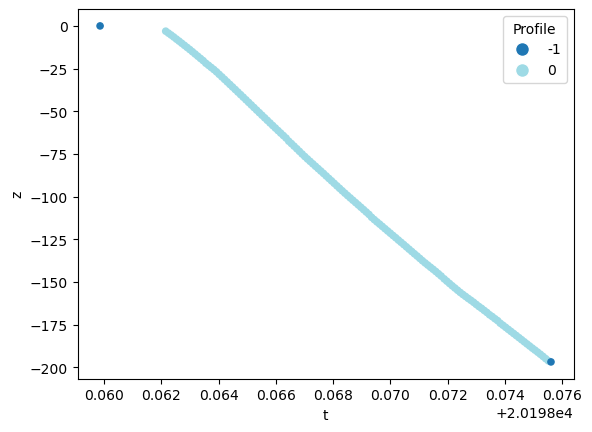

ASCII:  ../../gutils/tests/resources/slocum/bass-test-ascii/rt/ascii/usf_bass_2016_252_1_0_sbd.dat
usf_bass_2016_252_1_0_sbd.dat


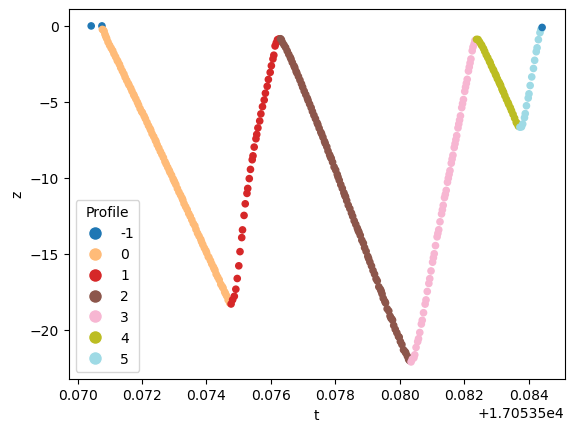

ASCII:  ../../gutils/tests/resources/slocum/bass-test-ascii/rt/ascii/usf_bass_2016_252_1_6_sbd.dat
usf_bass_2016_252_1_6_sbd.dat


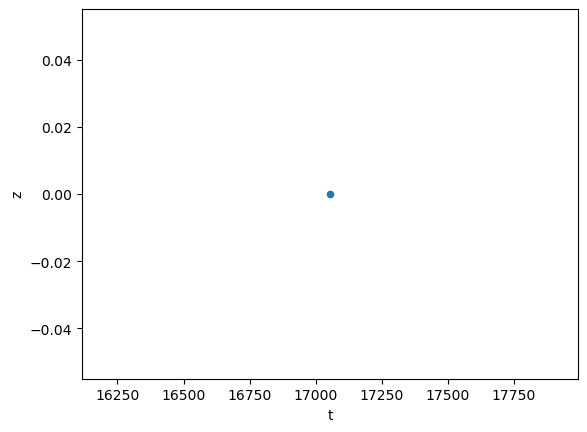

ASCII:  ../../gutils/tests/resources/slocum/bass-test-ascii/rt/ascii/usf_bass_2016_252_1_8_sbd.dat
usf_bass_2016_252_1_8_sbd.dat


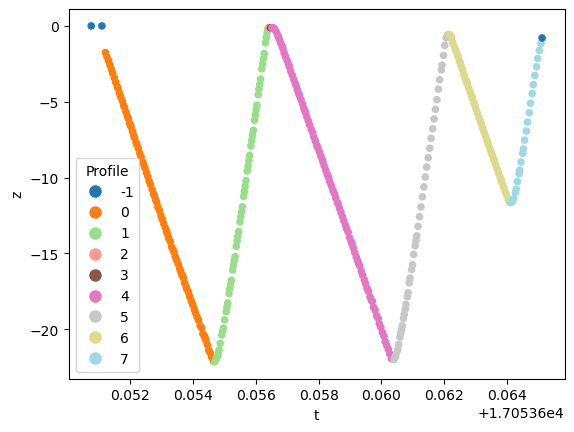

ASCII:  ../../gutils/tests/resources/slocum/bass-test-ascii/rt/ascii/usf_bass_2016_252_1_11_sbd.dat
usf_bass_2016_252_1_11_sbd.dat


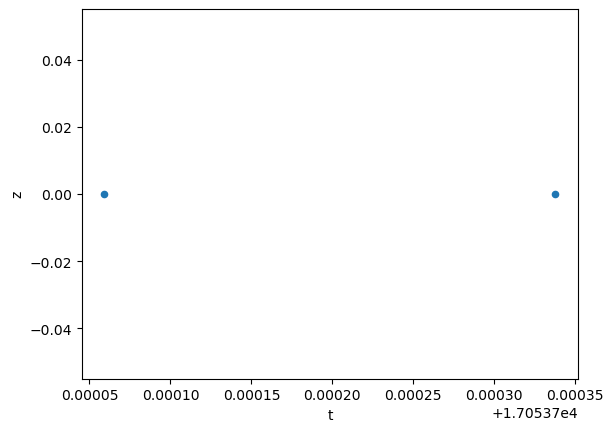

ASCII:  ../../gutils/tests/resources/slocum/bass-test-ascii/rt/ascii/usf_bass_2016_252_1_17_sbd.dat
usf_bass_2016_252_1_17_sbd.dat


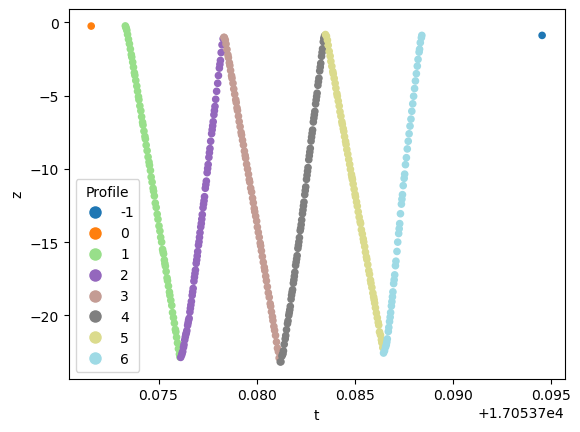

ASCII:  ../../gutils/tests/resources/slocum/bass-test-ascii/rt/ascii/usf_bass_2016_253_0_1_sbd.dat
usf_bass_2016_253_0_1_sbd.dat


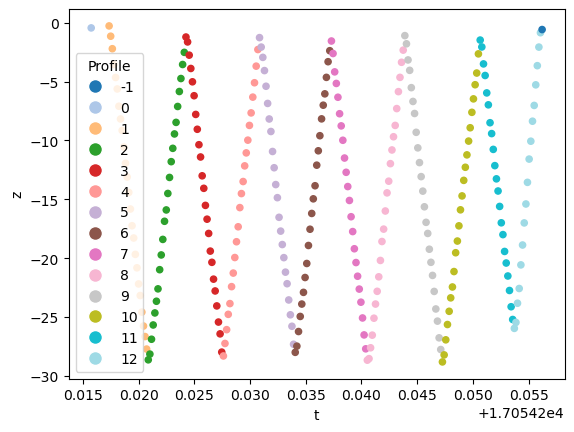

ASCII:  ../../gutils/tests/resources/slocum/bass-test-ascii/rt/ascii/usf_bass_2016_253_0_4_sbd.dat
usf_bass_2016_253_0_4_sbd.dat


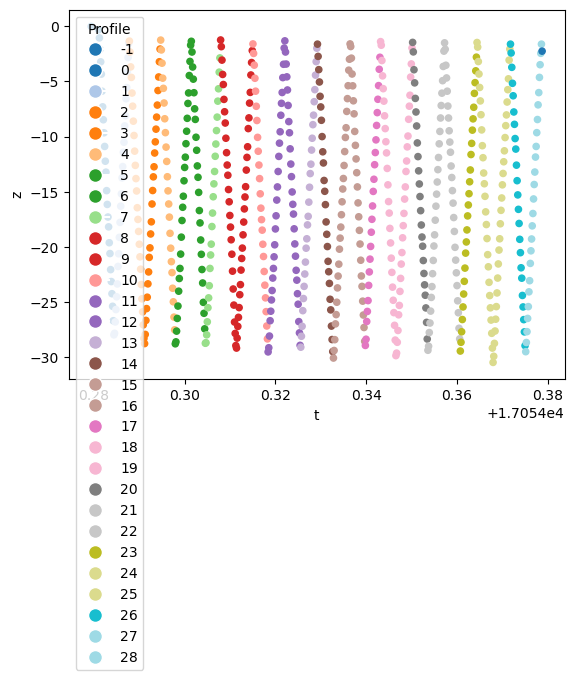

ASCII:  ../../gutils/tests/resources/slocum/bass-test-ascii/rt/ascii/usf_bass_2016_253_0_6_sbd.dat
usf_bass_2016_253_0_6_sbd.dat


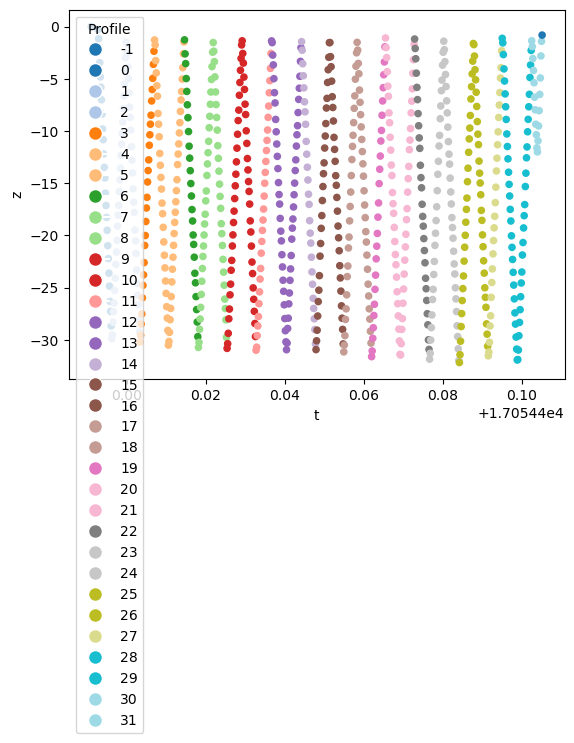

ASCII:  ../../gutils/tests/resources/slocum/modena-test-ascii/delayed/ascii/modena_2015_175_0_9_dbd.dat
modena_2015_175_0_9_dbd.dat


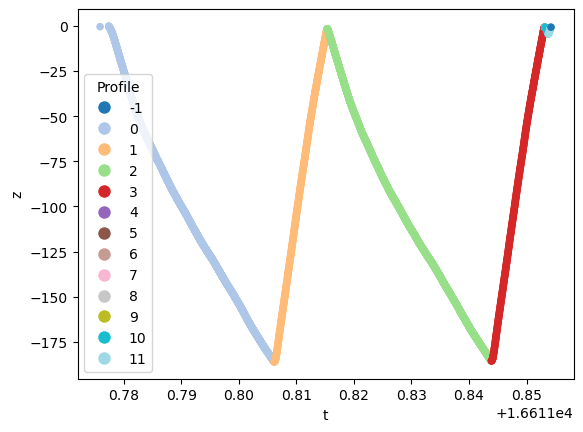

In [5]:
from gutils.yo import assign_profiles

paths = [
    'gutils/tests/resources/slocum/unit_191-20250226T0000/rt/ascii/unit_191_2025_069_2_355_sbd.dat',
    'gutils/tests/resources/slocum/unit_191-20250226T0000/rt/ascii/unit_191_2025_059_1_17_sbd.dat',
    'gutils/tests/resources/slocum/unit_191-20250226T0000/rt/ascii/unit_191_2025_098_0_16_sbd.dat',
    'gutils/tests/resources/slocum/unit_191-20250226T0000/rt/ascii/unit_191_2025_069_2_45_sbd.dat',
    'gutils/tests/resources/slocum/unit_191-20250226T0000/rt/ascii/unit_191_2025_098_0_14_sbd.dat',
    'gutils/tests/resources/slocum/unit_191-20250226T0000/rt/ascii/unit_191_2025_069_2_23_sbd.dat',
    'gutils/tests/resources/slocum/unit_191-20250226T0000/rt/ascii/unit_191_2025_069_2_198_sbd.dat',
    'gutils/tests/resources/slocum/unit_191-20250226T0000/rt/ascii/unit_191_2025_063_0_16_sbd.dat',
    'gutils/tests/resources/slocum/unit_191-20250226T0000/rt/ascii/unit_191_2025_063_0_24_sbd.dat',
    'gutils/tests/resources/slocum/unit_191-20250226T0000/rt/ascii/unit_191_2025_098_0_145_sbd.dat',
    'gutils/tests/resources/slocum/bass-test-ascii/rt/ascii/usf_bass_2016_252_1_0_sbd.dat',
    'gutils/tests/resources/slocum/bass-test-ascii/rt/ascii/usf_bass_2016_252_1_6_sbd.dat',
    'gutils/tests/resources/slocum/bass-test-ascii/rt/ascii/usf_bass_2016_252_1_8_sbd.dat',
    'gutils/tests/resources/slocum/bass-test-ascii/rt/ascii/usf_bass_2016_252_1_11_sbd.dat',
    'gutils/tests/resources/slocum/bass-test-ascii/rt/ascii/usf_bass_2016_252_1_17_sbd.dat',
    'gutils/tests/resources/slocum/bass-test-ascii/rt/ascii/usf_bass_2016_253_0_1_sbd.dat',
    'gutils/tests/resources/slocum/bass-test-ascii/rt/ascii/usf_bass_2016_253_0_4_sbd.dat',
    'gutils/tests/resources/slocum/bass-test-ascii/rt/ascii/usf_bass_2016_253_0_6_sbd.dat',
    'gutils/tests/resources/slocum/modena-test-ascii/delayed/ascii/modena_2015_175_0_9_dbd.dat',
]

for pth in paths:
    df = ascii_into_df(f'../../{pth}')
    profiles = assign_profiles(df)
    print(pth.split('/')[-1])
    plot_z(df if profiles is None else profiles)